# Skewed column scaling analysis

This notebook reproduces the reasoning used so far for the internet-speed variables and extends it to other strongly skewed columns in the dataset.

The workflow is:
1. Load the CSV and convert values such as commas and dashes into usable numeric data.
2. Identify skewed columns.
3. Compare three transformations for each selected column:
   - full-range min-max
   - 5th to 95th percentile capped min-max
   - log-transformed min-max
4. Summarize which approach is most useful for a report that needs a stable and interpretable normalization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")

csv_path = Path("SIDE 2026 - Rohan - Absolute.csv")
df = pd.read_csv(csv_path, dtype=str, keep_default_na=False)

print("Loaded rows:", len(df))
print("Columns:", len(df.columns))
print(df.head(2).to_string())

Loaded rows: 74
Columns: 78
     Country Price of mobile data and voice basket (HC)  (PPP) Price of mobile data and voice basket (LC) (PPP) Price of cheapest smartphone (PPP$) Price of fixed broadband internet (PPP) Median Mobile Download Speeds (Mbps) Median Fixed Broadband Download Speed (Mbps) Number of Internet Users (absolute numbers) Mobile Cellular Subscriptions in millions (absolute numbers) Population covered by LTE (Absolute numbers) Number of smartphone users (million) Gender gap - Number of women that need to use the internet (or stop using the internet, if negative) to achieve parity in internet penetration rate Number of internet users (16-64 years) using social media for work related activities Number of users of digital food delivery platforms (millions) Number of users of digital health applications  Number of e-commerce users Consumer Spend on Mobile Apps (millions USD) Number of video on demand users Fixed-broadband Internet traffic (EB) Mobile broadband internet tra

In [2]:

def parse_numeric(series: pd.Series) -> pd.Series:
    cleaned = series.astype(str).str.strip()
    cleaned = cleaned.replace({"": np.nan, "-": np.nan, "—": np.nan, "–": np.nan})
    cleaned = cleaned.str.replace(",", "", regex=False)
    return pd.to_numeric(cleaned, errors="coerce")


# Keep the country identifier and select the most relevant numeric columns.
selected_columns = [
    "Median Mobile Download Speeds (Mbps)",
    "Median Fixed Broadband Download Speed (Mbps)",
    "Number of Internet Users (absolute numbers)",
    "Mobile Cellular Subscriptions in millions (absolute numbers)",
    "Population covered by LTE (Absolute numbers)",
    "Number of smartphone users (million)",
    "Fixed-broadband Internet traffic (EB)",
    "Mobile broadband internet traffic (EB)",
    "Value of digital payment transactions (millions of dollars)",
    "Users of Digital Payments (in millions)",
    "ICT Services Export  (million USD)",
    "Total digitally delivered services (million USD)",
    "IT market Capitalisation in USD",
]

available_columns = [col for col in selected_columns if col in df.columns]

numeric_df = pd.DataFrame({"Country": df["Country"]})
for col in available_columns:
    numeric_df[col] = parse_numeric(df[col])

# Show how skewed each selected column is.
skewness_summary = []
for col in available_columns:
    values = numeric_df[col].dropna()
    if len(values) >= 5:
        skewness_summary.append({
            "column": col,
            "non_missing": int(values.size),
            "skewness": float(values.skew()),
            "p05": float(values.quantile(0.05)),
            "p95": float(values.quantile(0.95)),
            "max": float(values.max()),
        })

skewness_summary = pd.DataFrame(skewness_summary).sort_values("skewness", ascending=False)
print(skewness_summary.to_string(index=False))

# Keep the columns that look clearly right-skewed.
columns_to_analyze = skewness_summary.loc[skewness_summary["skewness"] >= 1.0, "column"].tolist()
print("\nColumns to analyze:")
for col in columns_to_analyze:
    print("-", col)

                                                      column  non_missing  skewness          p05          p95          max
                       Fixed-broadband Internet traffic (EB)           62  7.543746       0.6250 1.500450e+02 2.209700e+03
                             IT market Capitalisation in USD           45  6.649866     296.8000 1.014556e+06 2.557494e+07
 Value of digital payment transactions (millions of dollars)           68  6.459471   10600.5000 7.372050e+05 1.004000e+07
                     Users of Digital Payments (in millions)           68  6.377063       2.0755 1.207405e+02 1.001030e+03
                 Number of Internet Users (absolute numbers)           72  5.517391 4500664.4000 1.914500e+08 1.260000e+09
                        Number of smartphone users (million)           72  5.399463 3060411.9000 1.457000e+08 9.560000e+08
                      Mobile broadband internet traffic (EB)           71  5.398287       0.7500 4.455000e+01 3.461000e+02
Mobile Cellular 

In [3]:

def full_minmax(series: pd.Series) -> pd.Series:
    s = series.dropna()
    if s.max() == s.min():
        return pd.Series(0.0, index=s.index)
    return (s - s.min()) / (s.max() - s.min())


def capped_minmax(series: pd.Series, lower=0.05, upper=0.95) -> pd.Series:
    s = series.dropna()
    low = s.quantile(lower)
    high = s.quantile(upper)
    if high == low:
        return pd.Series(0.0, index=s.index)
    clipped = s.clip(lower=low, upper=high)
    return (clipped - low) / (high - low)


def log_minmax(series: pd.Series) -> pd.Series:
    s = series.dropna()
    logged = np.log1p(s)
    if logged.max() == logged.min():
        return pd.Series(0.0, index=s.index)
    return (logged - logged.min()) / (logged.max() - logged.min())


results = {}
for col in columns_to_analyze:
    s = numeric_df[col]
    results[col] = pd.DataFrame({
        "raw_value": s,
        "full_minmax": full_minmax(s),
        "capped_5_95_minmax": capped_minmax(s),
        "log_minmax": log_minmax(s),
    })

# Print a compact example for two columns.
for col in columns_to_analyze[:3]:
    print("\n" + col)
    print(results[col].head(8).to_string())


Fixed-broadband Internet traffic (EB)
   raw_value  full_minmax  capped_5_95_minmax  log_minmax
0       15.9     0.007196            0.102229    0.367133
1        NaN          NaN                 NaN         NaN
2       49.7     0.022492            0.328437    0.509790
3        7.0     0.003168            0.042665    0.270020
4       16.1     0.007286            0.103567    0.368661
5       17.4     0.007874            0.112267    0.378175
6       96.2     0.043535            0.639640    0.594304
7        9.3     0.004209            0.058058    0.302834

IT market Capitalisation in USD
   raw_value  full_minmax  capped_5_95_minmax  log_minmax
0        NaN          NaN                 NaN         NaN
1     1027.0     0.000040            0.000720    0.333995
2    62632.0     0.002449            0.061459    0.604409
3        NaN          NaN                 NaN         NaN
4      372.0     0.000014            0.000074    0.267288
5        NaN          NaN                 NaN         NaN


In [4]:
# Create a summary table of the transformed values for each column.
summary_rows = []
for col in columns_to_analyze:
    transformed = results[col]
    raw = transformed["raw_value"].dropna()
    full = transformed["full_minmax"].dropna()
    capped = transformed["capped_5_95_minmax"].dropna()
    logged = transformed["log_minmax"].dropna()

    summary_rows.append({
        "column": col,
        "skewness": float(raw.skew()),
        "full_minmax_q90": float(full.quantile(0.90)),
        "capped_q90": float(capped.quantile(0.90)),
        "log_q90": float(logged.quantile(0.90)),
        "full_minmax_std": float(full.std()),
        "capped_std": float(capped.std()),
        "log_std": float(logged.std()),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("skewness", ascending=False)
print(summary_df.to_string(index=False))

                                                      column  skewness  full_minmax_q90  capped_q90  log_q90  full_minmax_std  capped_std  log_std
                       Fixed-broadband Internet traffic (EB)  7.543746         0.061434    0.904330 0.638490         0.126688    0.318171 0.189759
                             IT market Capitalisation in USD  6.649866         0.023092    0.581991 0.750618         0.148747    0.284950 0.184734
 Value of digital payment transactions (millions of dollars)  6.459471         0.037399    0.502187 0.774132         0.132192    0.274992 0.131320
                     Users of Digital Payments (in millions)  6.377063         0.062011    0.517874 0.538231         0.130448    0.270158 0.206438
                 Number of Internet Users (absolute numbers)  5.517391         0.083333    0.537575 0.873836         0.140136    0.271832 0.114980
                        Number of smartphone users (million)  5.399463         0.079211    0.509433 0.869417         0

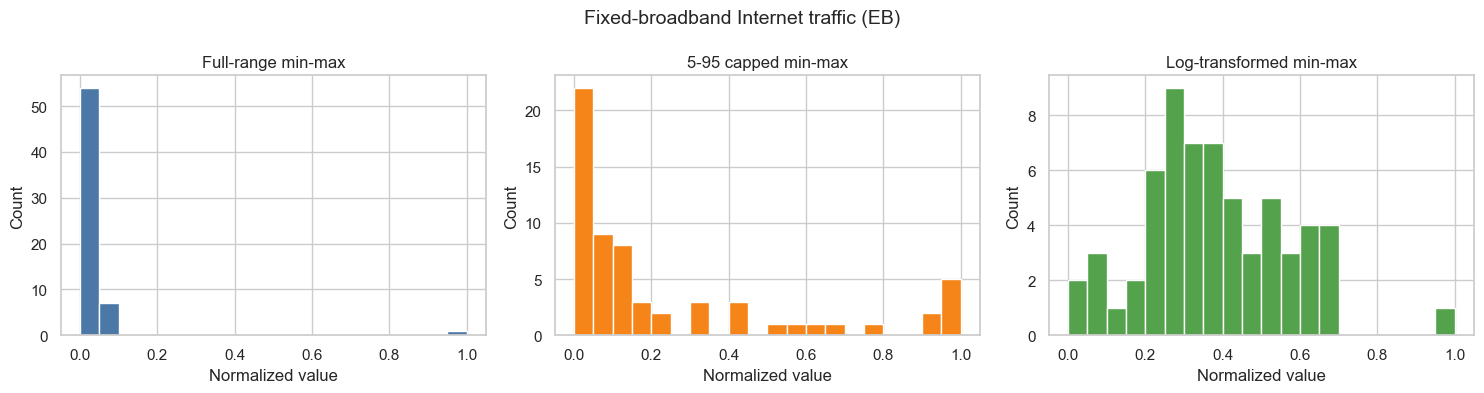

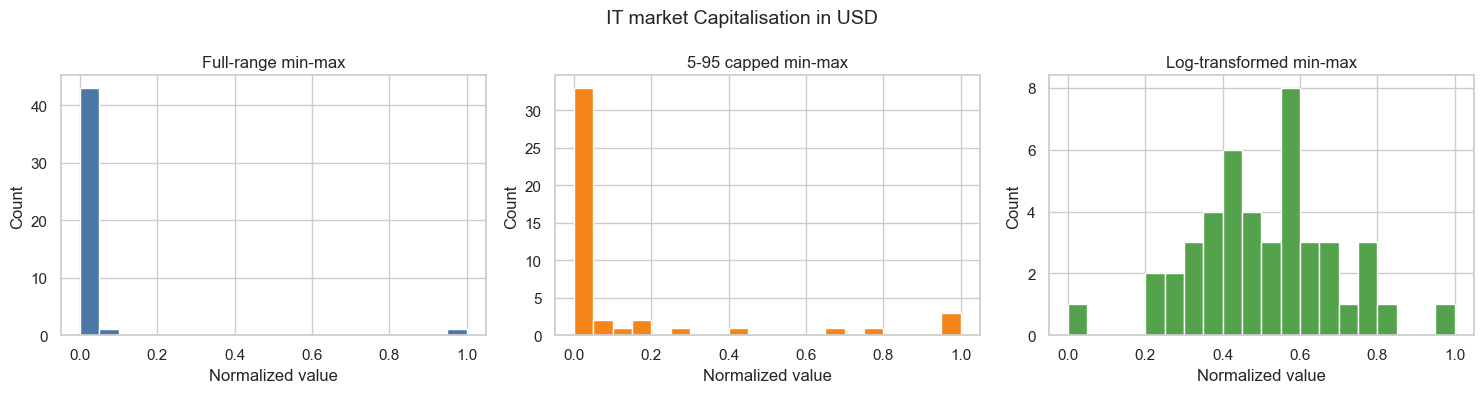

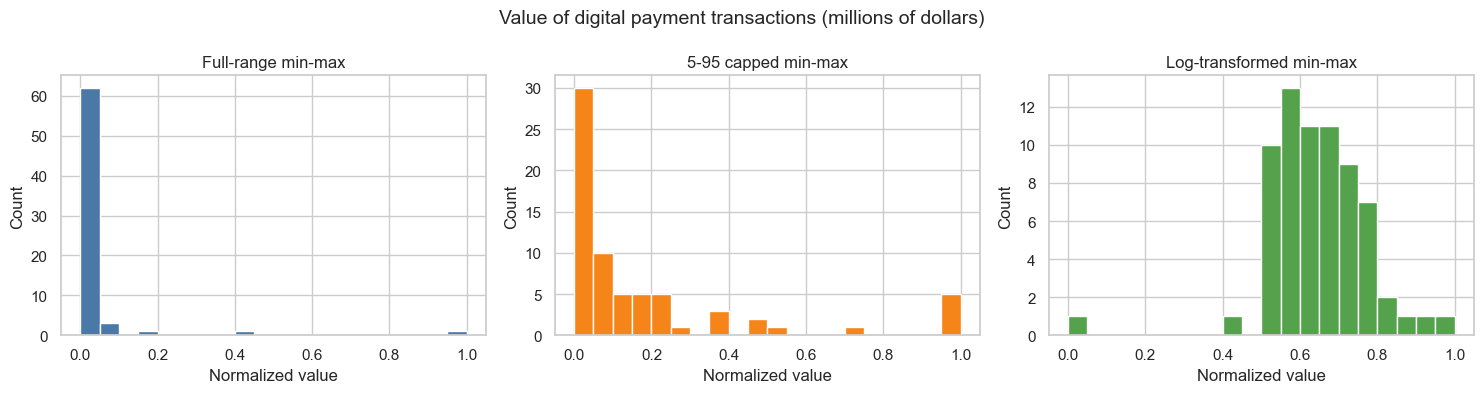

In [5]:
# Visual comparison for the first three skewed columns.
for col in columns_to_analyze[:3]:
    transformed = results[col]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].hist(transformed["full_minmax"].dropna(), bins=20, color="#4C78A8")
    axes[0].set_title("Full-range min-max")
    axes[0].set_xlabel("Normalized value")
    axes[0].set_ylabel("Count")

    axes[1].hist(transformed["capped_5_95_minmax"].dropna(), bins=20, color="#F58518")
    axes[1].set_title("5-95 capped min-max")
    axes[1].set_xlabel("Normalized value")
    axes[1].set_ylabel("Count")

    axes[2].hist(transformed["log_minmax"].dropna(), bins=20, color="#54A24B")
    axes[2].set_title("Log-transformed min-max")
    axes[2].set_xlabel("Normalized value")
    axes[2].set_ylabel("Count")

    fig.suptitle(col, fontsize=14)
    plt.tight_layout()
    plt.show()

## Interpretation for the report

The three approaches answer slightly different questions:

- Full-range min-max is simple and easy to explain, but it can be overly influenced by a few very large observations.
- 5th to 95th percentile capped min-max is usually the most robust choice when the goal is to preserve relative ranking without letting a small number of outliers dominate the scale.
- Log-transformed min-max is helpful when the report wants to reflect percentage differences and compress the upper tail, but it is less intuitive for a general audience and can make the middle of the distribution look more compressed.

For most policy and comparative-report purposes, the capped 5-95 min-max approach is often the most useful because it keeps the scaling stable and interpretable while reducing the distortion caused by extreme values.

In [6]:
# A compact recommendation statement that can be copied into a report.
for col in columns_to_analyze[:4]:
    transformed = results[col]
    full = transformed["full_minmax"].dropna()
    capped = transformed["capped_5_95_minmax"].dropna()
    logged = transformed["log_minmax"].dropna()

    print(col)
    print("- full-range min-max: mean", round(float(full.mean()), 3), "std", round(float(full.std()), 3))
    print("- capped 5-95 min-max: mean", round(float(capped.mean()), 3), "std", round(float(capped.std()), 3))
    print("- log min-max: mean", round(float(logged.mean()), 3), "std", round(float(logged.std()), 3))
    print()

Fixed-broadband Internet traffic (EB)
- full-range min-max: mean 0.032 std 0.127
- capped 5-95 min-max: mean 0.248 std 0.318
- log min-max: mean 0.378 std 0.19

IT market Capitalisation in USD
- full-range min-max: mean 0.027 std 0.149
- capped 5-95 min-max: mean 0.138 std 0.285
- log min-max: mean 0.508 std 0.185

Value of digital payment transactions (millions of dollars)
- full-range min-max: mean 0.035 std 0.132
- capped 5-95 min-max: mean 0.18 std 0.275
- log min-max: mean 0.646 std 0.131

Users of Digital Payments (in millions)
- full-range min-max: mean 0.041 std 0.13
- capped 5-95 min-max: mean 0.184 std 0.27
- log min-max: mean 0.288 std 0.206

